<a href="https://colab.research.google.com/github/internetOnion/machine-learning-101/blob/main/cat_or_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Is the image a dog or a cat or something else? using image binary classification model

## Setting up environments

In [1]:
!python --version
!pip --version

Python 3.12.13
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [2]:
!pip install -U fastai "fastcore<2.0" ddgs kagglehub

INFO: pip is looking at multiple versions of python-fasthtml to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.1/108.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.4/80.4 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing installation: fastcore 2.0.5
    Uninstalling fastcore-2.0.5:
      Successfully uninstalled fastcore-2.0.5
  Attempting uninstall: python-fasthtml
    Found existing installation: python-fasthtml 0.14.6
    Uninstalling python-fasthtml-0.14.6:
      Successfully uninstalled python-fasthtml-0.14.6


## Download datasets

In [3]:
import kagglehub

cat_and_dog_path = kagglehub.dataset_download("tongpython/cat-and-dog")

print(f"Path to dataset files: {cat_and_dog_path}")

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [4]:
from fastcore.all import *
from fastai.vision.all import *
from fastdownload import download_url

In [5]:
dest_cat = Path('cat')
dest_cat.mkdir(exist_ok=True, parents=True)
dest_dog = Path('dog')
dest_dog.mkdir(exist_ok=True, parents=True)

resize_images(
    Path(cat_and_dog_path, 'test_set/test_set/cats'),
    max_size=400,
    dest=Path(dest_cat)
)
resize_images(
    Path(cat_and_dog_path, 'training_set/training_set/cats'),
    max_size=400,
    dest=Path(dest_cat)
)

resize_images(
    Path(cat_and_dog_path, 'test_set/test_set/dogs'),
    max_size=400,
    dest=Path(dest_dog)
)
resize_images(
    Path(cat_and_dog_path, 'training_set/training_set/dogs'),
    max_size=400,
    dest=Path(dest_dog)
)

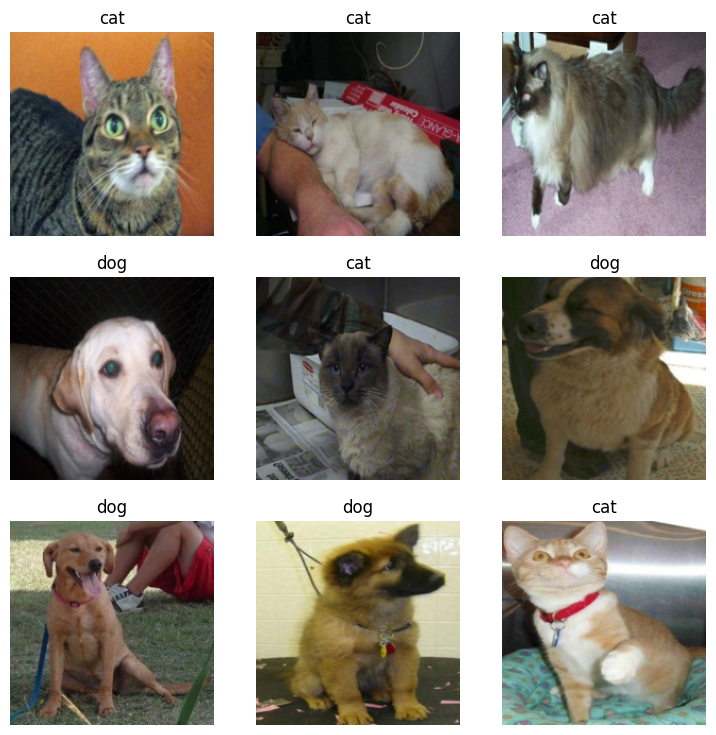

In [10]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(Path('.'), bs=128)

dls.show_batch(max_n=9)

In [11]:
print(f"train: {len(dls.train_ds)}")
print(f"valid: {len(dls.valid_ds)}")

train: 8023
valid: 2005


In [22]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(10)

epoch,train_loss,valid_loss,error_rate,time
0,0.175021,0.101255,0.033416,00:31


epoch,train_loss,valid_loss,error_rate,time
0,0.079812,0.062125,0.024439,00:37
1,0.048046,0.067696,0.020948,00:32
2,0.037515,0.074119,0.021945,00:33
3,0.024729,0.072596,0.021446,00:32
4,0.008829,0.041914,0.013466,00:33
5,0.011190,0.047217,0.014963,00:32
6,0.004681,0.064339,0.017456,00:34
7,0.002932,0.065876,0.015960,00:34
8,0.001460,0.047265,0.012968,00:35
9,0.001116,0.046743,0.012968,00:34


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

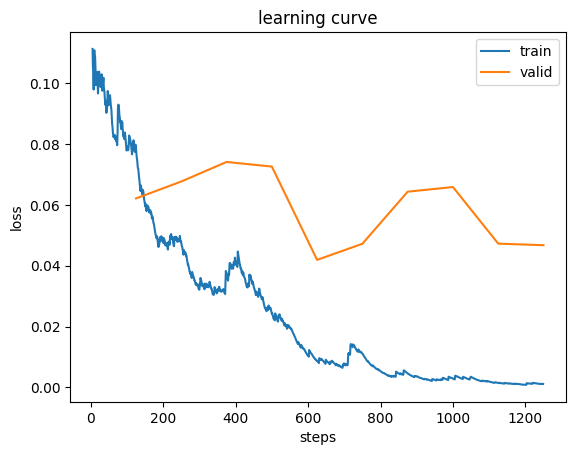

In [23]:
learn.recorder.plot_loss()